<a href="https://colab.research.google.com/github/Mohamed-777222/NoteBooks/blob/main/Airbnb_Open_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np   #pta-000 #pta-123 #pta-122 #pta-332
import pandas as pd

In [2]:
print(" Loading dataset...")

df = pd.read_csv("/content/drive/MyDrive/Airbnb_Open_Data.csv", low_memory=False)
print(f"Original Dataset Shape: {df.shape}")

 Loading dataset...
Original Dataset Shape: (102599, 26)


In [3]:
df

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN


#Cleaning Data

In [4]:
print("\n Checking for missing values...")

missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])


 Checking for missing values...


,0
NAME,250
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532
country code,131
instant_bookable,105


In [5]:
unique_groups = df['neighbourhood group'].unique()
unique_groups = [group for group in unique_groups if pd.notna(group)]
num_groups = len(unique_groups)

print(f"Number of neighbourhood groups: {num_groups}")
print("Neighbourhood groups:")
for group in unique_groups:
    print(f"- {group}")

Number of neighbourhood groups: 7
Neighbourhood groups:
- Brooklyn
- Manhattan
- brookln
- manhatan
- Queens
- Staten Island
- Bronx


In [6]:
print("\n Cleaning data...")

df = df.copy()
df = df.drop_duplicates()
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].astype(str).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False)
df['service fee'] = df['service fee'].astype(str).str.replace(',', '', regex=False)
df['service fee'] = pd.to_numeric(df['service fee'], errors='coerce')

# Added errors='ignore' to prevent KeyError if columns are already dropped
df = df.drop(columns=['id', 'NAME', 'host id', 'host name', 'house_rules', 'license', 'country', 'country code'], errors='ignore')

corr = {'brookln': 'Brooklyn', 'manhatan': 'Manhattan'}
df['neighbourhood group'] = df['neighbourhood group'].replace(corr)


 Cleaning data...


In [7]:
print("\n Filling missing values...")

price_middle = df['price'].median()
df['price'] = df['price'].fillna(price_middle)
fee_middle = df['service fee'].median()
df['service fee'] = df['service fee'].fillna(fee_middle)
df['neighbourhood group'] = df['neighbourhood group'].fillna('Unknown')
df['instant_bookable'] = df['instant_bookable'].replace({'TRUE': True, 'FALSE': False, 'True': True, 'False': False})
df = df[df['instant_bookable'].isin([True, False])]
df['host_identity_verified'] = df['host_identity_verified'].fillna('Unconfirmed')
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')

df['lat'] = df.groupby('neighbourhood group')['lat'].transform(lambda x: x.fillna(x.median()))
df['long'] = df.groupby('neighbourhood group')['long'].transform(lambda x: x.fillna(x.median()))
df['lat'] = df['lat'].fillna(df['lat'].median())
df['long'] = df['long'].fillna(df['long'].median())

optimal_year = df['Construction year'].median()
df['Construction year'] = df['Construction year'].fillna(optimal_year).astype(int)

for col in ['minimum nights', 'calculated host listings count', 'review rate number', 'availability 365']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

df['number of reviews'] = df['number of reviews'].fillna(0)
df['reviews per month'] = df['reviews per month'].fillna(0.0)

df['last review'] = df['last review'].fillna('No Reviews')


 Filling missing values...


In [8]:
pd.set_option('future.no_silent_downcasting', True)
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())
text_columns = df.select_dtypes(include=["object"]).columns
for col in text_columns:
    df[col] = df[col].fillna("Unknown").infer_objects(copy=False)
df["instant_bookable"] = df["instant_bookable"].replace(
    {"TRUE": True, "FALSE": False, "True": True, "False": False}
)
df = df[df["instant_bookable"].isin([True, False])]

In [9]:
print("\n Verification Check:")
total_nans_left = df.isna().sum().sum()
print(f"Total NaN values remaining in the whole dataset: {total_nans_left}")


 Verification Check:
Total NaN values remaining in the whole dataset: 0


Imbalance is when different categories of data is not displayed equally resulting in bias or poor prediction


In [10]:
print("\n Checking for Class Imbalance...")

print(df['instant_bookable'].value_counts())


 Checking for Class Imbalance...
instant_bookable
False    51186
True     50767
Name: count, dtype: int64


In [11]:
print("\n Balancing the dataset...")

df_false_group = df[df['instant_bookable'] == False]
df_true_group = df[df['instant_bookable'] == True]
target_size = len(df_false_group)
df_true_balanced = df_true_group.sample(target_size, replace=True, random_state=42)
df_final_balanced = pd.concat([df_false_group, df_true_balanced])
print("\n✅ Success! New balanced distribution:")
print(df_final_balanced['instant_bookable'].value_counts())


 Balancing the dataset...

✅ Success! New balanced distribution:
instant_bookable
False    51186
True     51186
Name: count, dtype: int64


In [12]:
df

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020,966.0,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007,142.0,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0
2,Unconfirmed,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005,620.0,124.0,3.0,0.0,No Reviews,0.00,5.0,1.0,352.0
3,unconfirmed,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005,368.0,74.0,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0
4,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009,204.0,41.0,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102053,unconfirmed,Brooklyn,Flatbush,40.64945,-73.96108,True,moderate,Private room,2012,696.0,125.0,7.0,12.0,3/27/2019,0.44,5.0,1.0,0.0
102054,verified,Brooklyn,Bushwick,40.69872,-73.92718,False,flexible,Private room,2012,909.0,125.0,1.0,19.0,8/31/2017,0.72,3.0,2.0,0.0
102055,verified,Brooklyn,Bedford-Stuyvesant,40.67810,-73.90822,True,moderate,Entire home/apt,2012,387.0,125.0,2.0,50.0,6/26/2019,3.12,4.0,2.0,235.0
102056,unconfirmed,Manhattan,Harlem,40.81248,-73.94317,True,strict,Private room,2012,848.0,125.0,2.0,0.0,No Reviews,0.00,1.0,1.0,0.0


**Data Visualization**



Bar chart

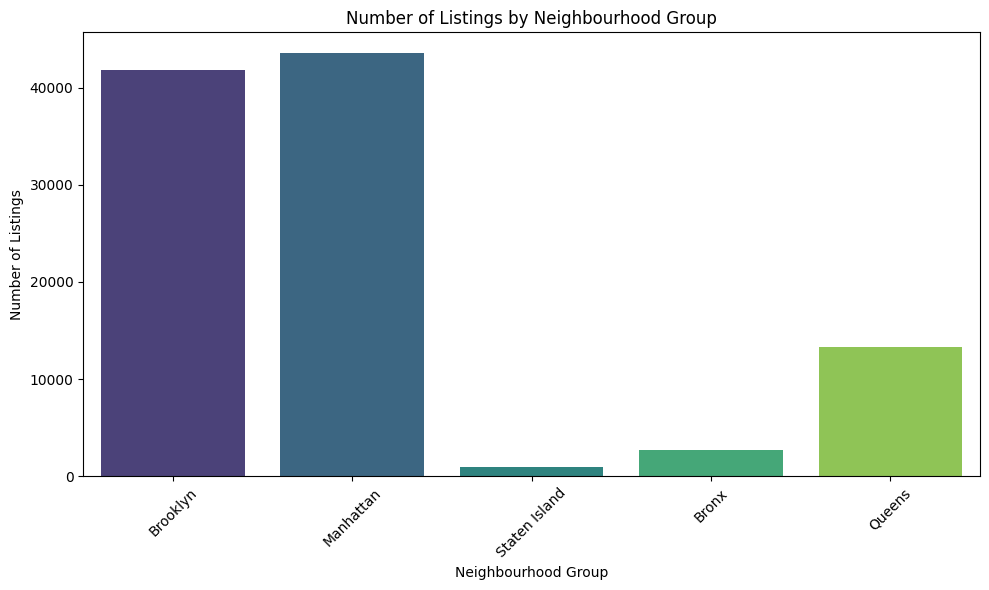

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_final_balanced.reset_index(drop=True)
df_plot = df_plot[df_plot['neighbourhood group'] != 'Unknown']

categories = list(df_plot['neighbourhood group'].unique())

plt.figure(figsize=(10, 6))
sns.countplot(
    x='neighbourhood group',
    data=df_plot,
    order=categories,
    palette='viridis',
    hue='neighbourhood group',
    legend=False
)
plt.title('Number of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Observation (Bar Chart - Neighbourhood Group)

The bar chart shows that Manhattan and Brooklyn have significantly more listings compared to other neighbourhood groups. This suggests these areas are popular for Airbnb rentals.

Histogram

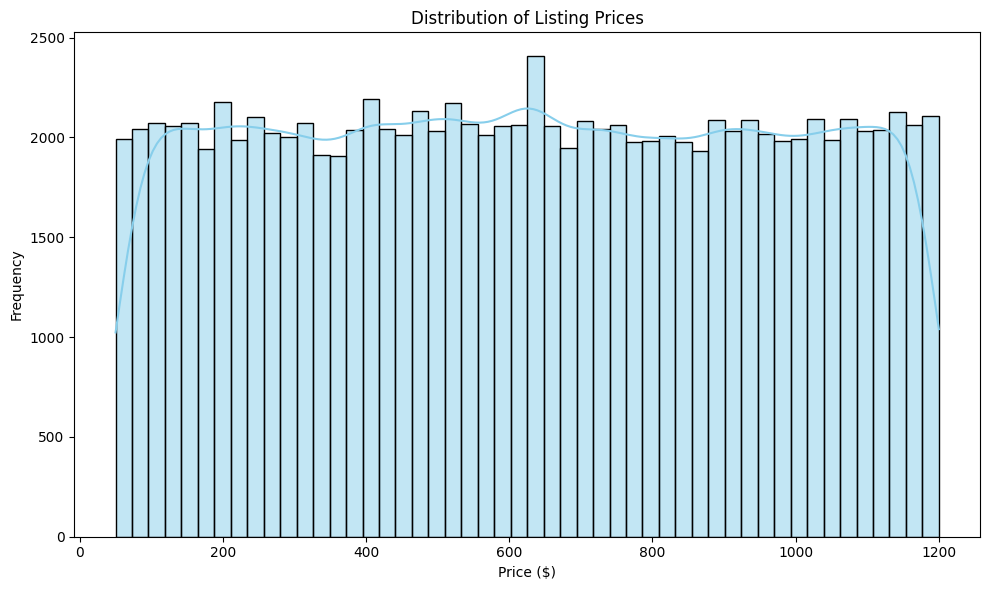

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final_balanced['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

 Observation (Histogram - Price Distribution)

The histogram indicates that the majority of listings are priced at the lower end, with a long tail extending towards higher prices. This suggests a skewed distribution, typical for pricing data, where most rentals are affordable, but a few high-end options exist.

scatter plot

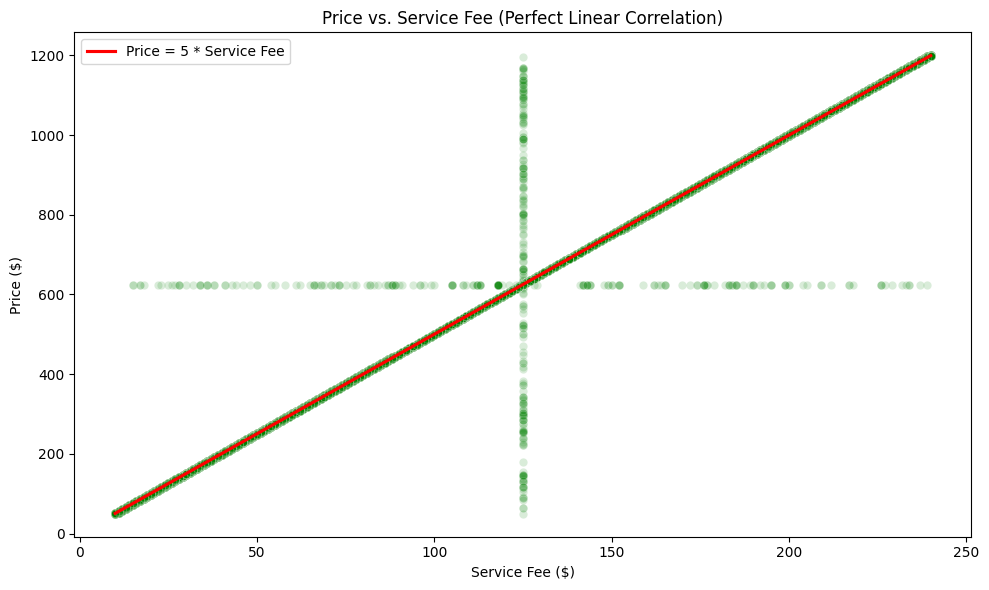

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='service fee', y='price', data=df_final_balanced, alpha=0.15, color='green')

sns.regplot(x='service fee', y='price', data=df_final_balanced, scatter=False, color='red', label='Price = 5 * Service Fee')

plt.title('Price vs. Service Fee (Perfect Linear Correlation)')
plt.xlabel('Service Fee ($)')
plt.ylabel('Price ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

 Observation (Scatter Plot - Price vs. Service Fee)

The scatter plot generally shows a positive correlation between price and service fee meaning that as the price of a listing increases, the service fee also tends to increase. However, there's a wide spread, indicating variability in how service fees are applied.

Box blot

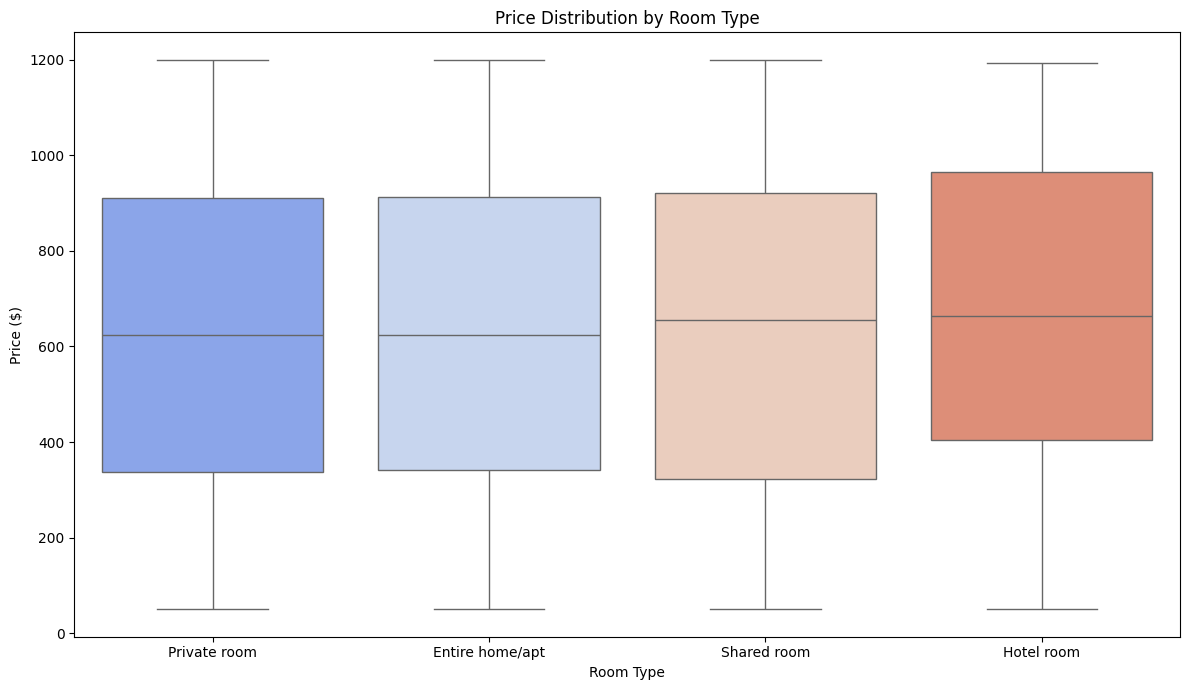

In [16]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='room type', y='price', data=df_final_balanced, palette='coolwarm', hue='room type', legend=False)
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

### Box Plot Findings

* **Price Uniformity:** Regardless of whether you book an entire home, a private room, or a shared room, the overall pricing scale spans almost identically from ~$50 to ~$1,200.
* **Identical Median Costs:** The typical rental rate sits at roughly $625 across all room categories, showing that room type does not strictly dictate a higher average cost in this dataset.
* **No Clear Premium Category:** Because the price distributions and midpoints overlap almost completely, room type alone is not a strong differentiator of price within this Airbnb dataset.

#Heatmap

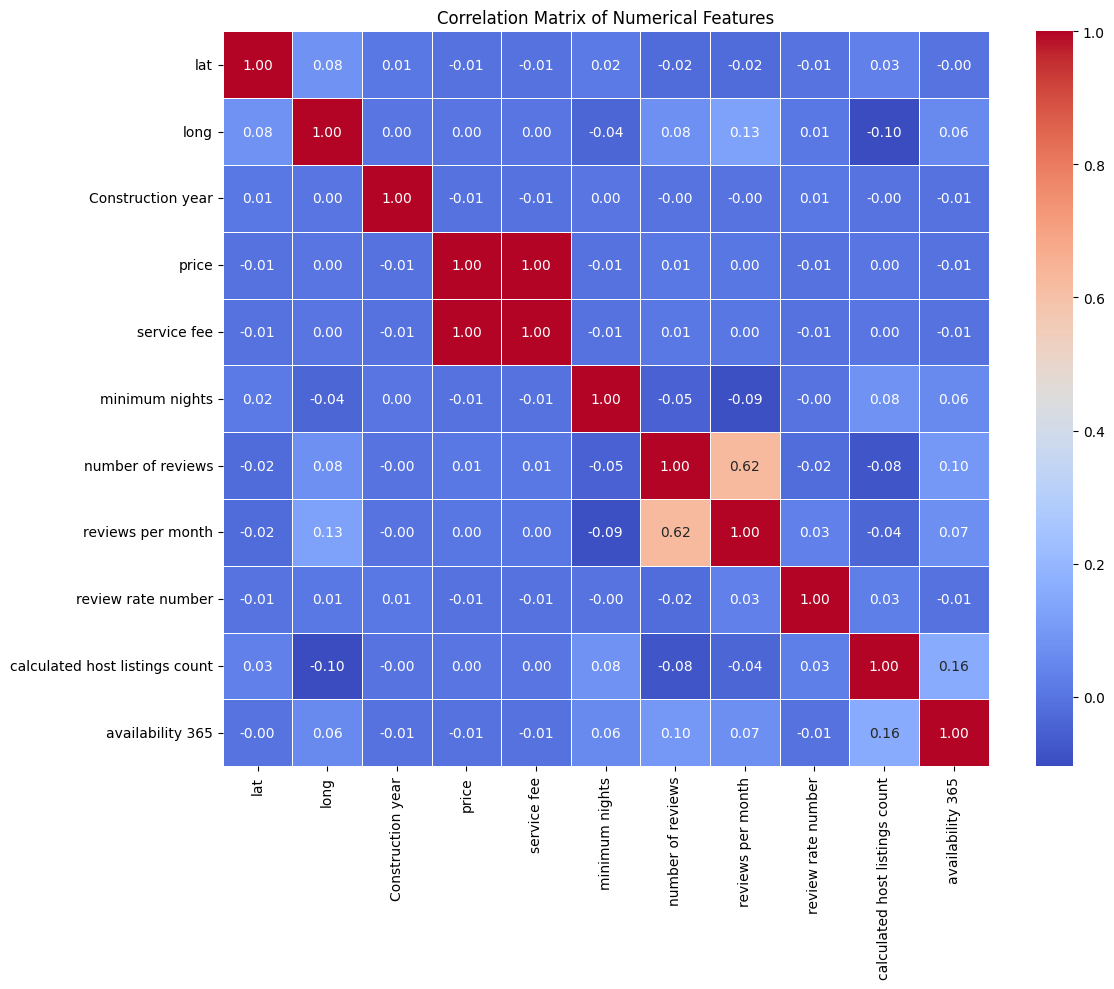

In [17]:
plt.figure(figsize=(12, 10))
numerical_cols = df_final_balanced.select_dtypes(include=np.number).columns
correlation_matrix = df_final_balanced[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

 Observation (Heatmap - Correlation Matrix)

The heatmap visualizes the relationships between numerical features. Strong positive correlations (closer to 1) are shown in lighter colors, and negative correlations (closer to -1) in darker colors. For example, price and service fee show a relatively strong positive correlation, while latitude and longitude show a very weak correlation. This helps identify which numerical features move together or in opposite directions.

Outlier Detection



1. IQR

In [18]:

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\nDetecting outliers using IQR method for 'price' column:")
price_outliers_iqr, lower_bound_iqr, upper_bound_iqr = detect_outliers_iqr(df_final_balanced, 'price')
print(f"Number of outliers detected: {len(price_outliers_iqr)}")
print(f"Lower bound: {lower_bound_iqr:.2f}, Upper bound: {upper_bound_iqr:.2f}")
if not price_outliers_iqr.empty:
    print("Sample of 'price' outliers (IQR method):")
    display(price_outliers_iqr[['price', 'service fee']].head())


Detecting outliers using IQR method for 'price' column:
Number of outliers detected: 0
Lower bound: -520.50, Upper bound: 1771.50


 2. Z-score


In [19]:
from scipy.stats import zscore

def detect_outliers_zscore(df, column, threshold=3):
    df['z_score'] = np.abs(zscore(df[column]))
    outliers = df[df['z_score'] > threshold]
    df = df.drop(columns=['z_score'])
    return outliers

print("\nDetecting outliers using Z-score method for 'price' column (threshold=3):")
price_outliers_zscore = detect_outliers_zscore(df_final_balanced.copy(), 'price')
print(f"Number of outliers detected: {len(price_outliers_zscore)}")
if not price_outliers_zscore.empty:
    print("Sample of 'price' outliers (Z-score method):")
    display(price_outliers_zscore[['price', 'service fee']].head())


Detecting outliers using Z-score method for 'price' column (threshold=3):
Number of outliers detected: 0


In [20]:
df_final_balanced.to_csv('Airbnb_Processed_Data.csv', index=False)

print("Dataset exported successfully as 'Airbnb_Processed_Data.csv'!")

Dataset exported successfully as 'Airbnb_Processed_Data.csv'!


No outliers detected